In [1]:
# we will plot the error graphs
import numpy as np
import matplotlib.pyplot as plt
from utils import DATA_DIR

In [2]:
errors_dir = DATA_DIR /"tensors/fineweb_large/decomposition/"
methods = ["counting", "sc"]
dims = [1000, 1500, 2000, 2500, 3000]
ranks = [100, 150]
iters = 2500

In [3]:
errors = {}
for method in methods:
    for rank in ranks:
        for dim in dims:
            try:
                error = np.load(errors_dir / f"{method}_{dim}d_{rank}r_{iters}i_errors.npy")
                errors[(method, dim, rank)] = error
                print(f"Loaded error for {method} dim {dim} rank {rank}: {error[-1]}")
            except FileNotFoundError:
                print(f"File not found for {method} dim {dim} rank {rank}")
errors

Loaded error for counting dim 1000 rank 100: 0.06951969116926193
Loaded error for counting dim 1500 rank 100: 0.07366645336151123
Loaded error for counting dim 2000 rank 100: 0.07130364328622818
Loaded error for counting dim 2500 rank 100: 0.07212039083242416
Loaded error for counting dim 3000 rank 100: 0.07660509645938873
Loaded error for counting dim 1000 rank 150: 0.06351584196090698
Loaded error for counting dim 1500 rank 150: 0.0692276582121849
Loaded error for counting dim 2000 rank 150: 0.06709844619035721
Loaded error for counting dim 2500 rank 150: 0.06778702139854431
Loaded error for counting dim 3000 rank 150: 0.06567703187465668
Loaded error for sc dim 1000 rank 100: 0.9527009725570679
Loaded error for sc dim 1500 rank 100: 0.9630148410797119
Loaded error for sc dim 2000 rank 100: 0.9684941172599792
Loaded error for sc dim 2500 rank 100: 0.9717701077461243
Loaded error for sc dim 3000 rank 100: 0.9736299514770508
Loaded error for sc dim 1000 rank 150: 0.9411244988441467
Loa

{('counting',
  1000,
  100): array([0.7228061 , 0.53121877, 0.5173217 , ..., 0.06951831, 0.06951969,
        0.06951969], shape=(2051,), dtype=float32),
 ('counting',
  1500,
  100): array([0.7186597 , 0.5305595 , 0.5175126 , ..., 0.07367164, 0.07366905,
        0.07366645], shape=(2500,), dtype=float32),
 ('counting',
  2000,
  100): array([0.73386467, 0.5313271 , 0.51706374, ..., 0.07130364, 0.07130364,
        0.07130364], shape=(1686,), dtype=float32),
 ('counting',
  2500,
  100): array([0.7349743 , 0.53118503, 0.5169824 , ..., 0.07212039, 0.07212039,
        0.07212039], shape=(1863,), dtype=float32),
 ('counting',
  3000,
  100): array([0.7304551 , 0.5312867 , 0.5175689 , ..., 0.07660136, 0.0766026 ,
        0.0766051 ], shape=(1903,), dtype=float32),
 ('counting',
  1000,
  150): array([0.7174711 , 0.5297592 , 0.5167861 , ..., 0.06351584, 0.06351584,
        0.06351584], shape=(1661,), dtype=float32),
 ('counting',
  1500,
  150): array([0.7203158 , 0.5299173 , 0.51679265, ...

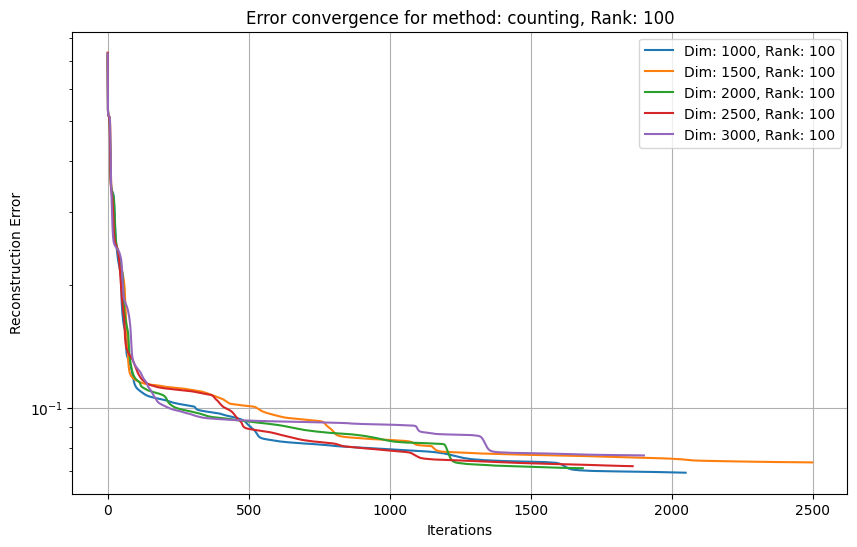

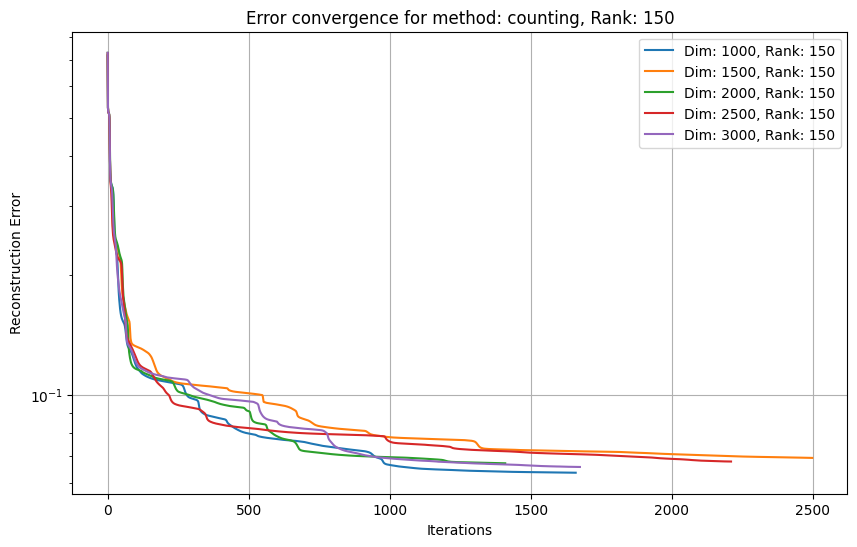

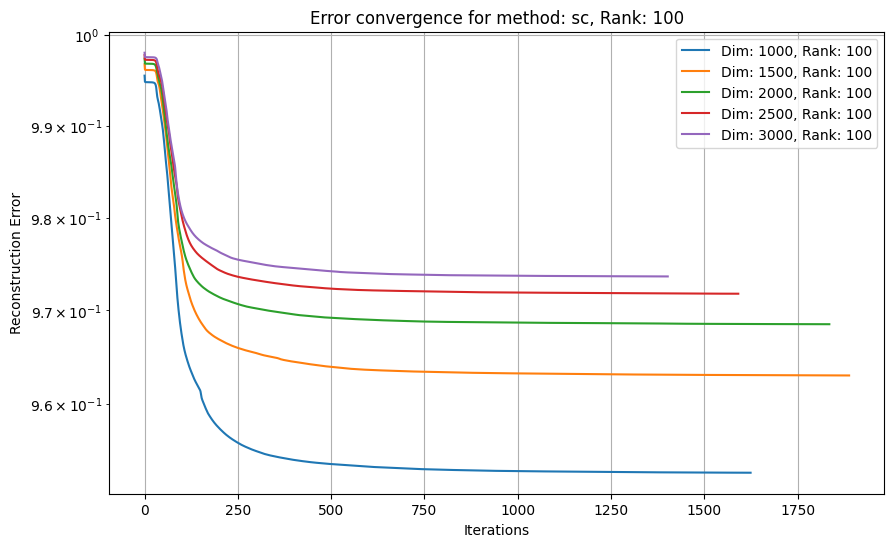

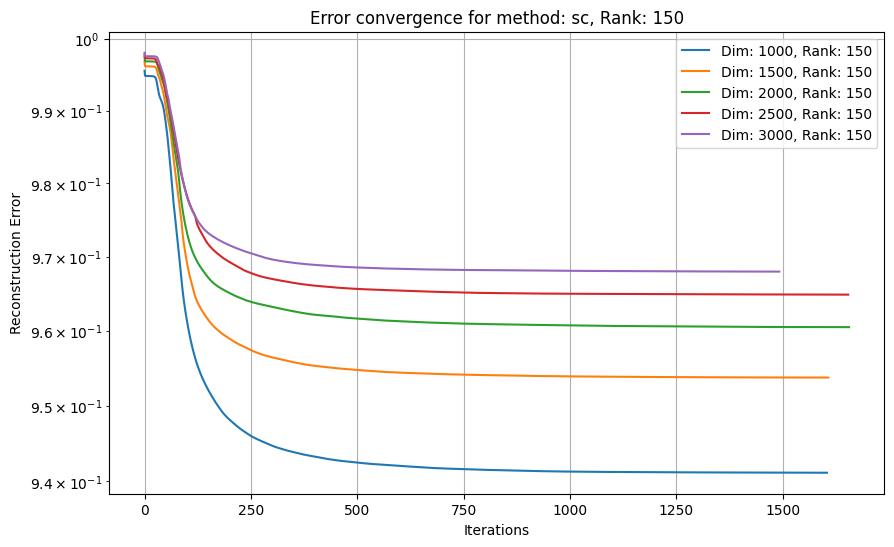

In [4]:
# we plot the errors for each method, dim and rank
for method in methods:
    for rank in ranks:
        plt.figure(figsize=(10, 6))
        for dim in dims:
            key = (method, dim, rank)
            if key in errors:
                plt.plot(errors[key], label=f"Dim: {dim}, Rank: {rank}")
        plt.title(f"Error convergence for method: {method}, Rank: {rank}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.yscale("log")
        plt.legend()
        plt.grid(True)
        plt.show()


# Semantic Error analysis


Loaded error for sc dim 1000 rank 150: 0.0188480741791619
Loaded error for sc dim 2000 rank 150: 0.025616008843949555
Loaded error for sc dim 3000 rank 150: 0.029506367959857158


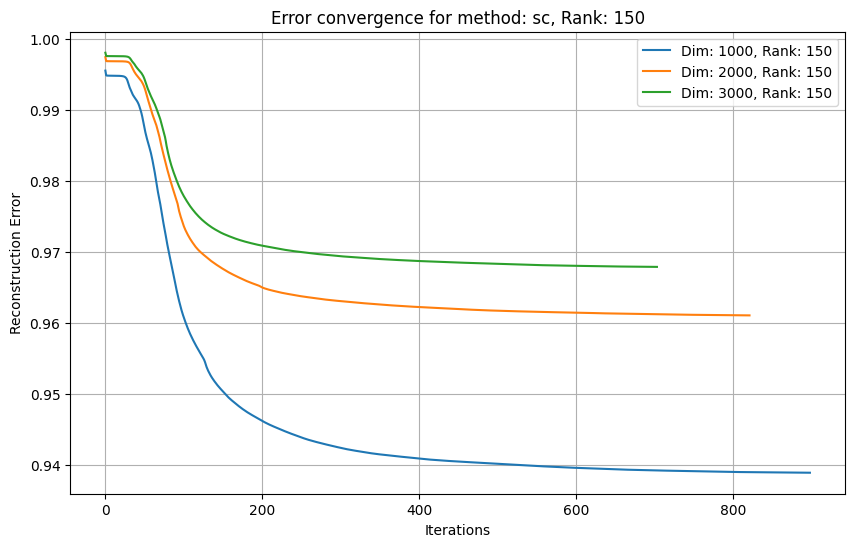

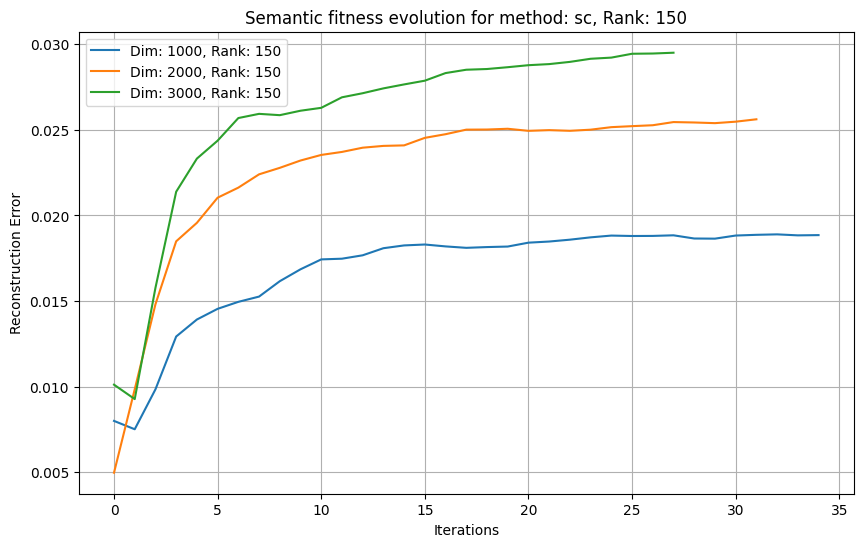

In [5]:
errors = {}
sem_errors = {}
methods = ["sc"]
dims = [1000, 2000, 3000]
ranks = [ 150]
iters = 2000
name = "sim"
for rank in ranks:
        for dim in dims:
            for method in methods:
                try:
                    error = np.load(errors_dir / f"{name}_{method}_{dim}d_{rank}r_{iters}i_errors.npy")
                    sem_error = np.load(errors_dir / f"{name}_{method}_{dim}d_{rank}r_{iters}i_fitness.npy")
                    errors[(method, dim, rank)] = error
                    sem_errors[(method, dim, rank)] = sem_error
                    print(f"Loaded error for {method} dim {dim} rank {rank}: {sem_error[-1]}")
                except FileNotFoundError:
                    print(f"File not found for {method} dim {dim} rank {rank}")
# we plot the errors for each method, dim and rank

for method in methods:
    for rank in ranks:
        plt.figure(figsize=(10, 6))
        for dim in dims:
            key = (method, dim, rank)
            if key in sem_errors:
                plt.plot(errors[key], label=f"Dim: {dim}, Rank: {rank}")
        plt.title(f"Error convergence for method: {method}, Rank: {rank}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()

for method in methods:
    for rank in ranks:
        plt.figure(figsize=(10, 6))
        for dim in dims:
            key = (method, dim, rank)
            if key in sem_errors:
                plt.plot(sem_errors[key], label=f"Dim: {dim}, Rank: {rank}")
        plt.title(f"Semantic fitness evolution for method: {method}, Rank: {rank}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()


Loaded error for sc dim 1000 rank 100: 0.013856982431714394
Loaded error for sc dim 1000 rank 150: 0.016243734553230967


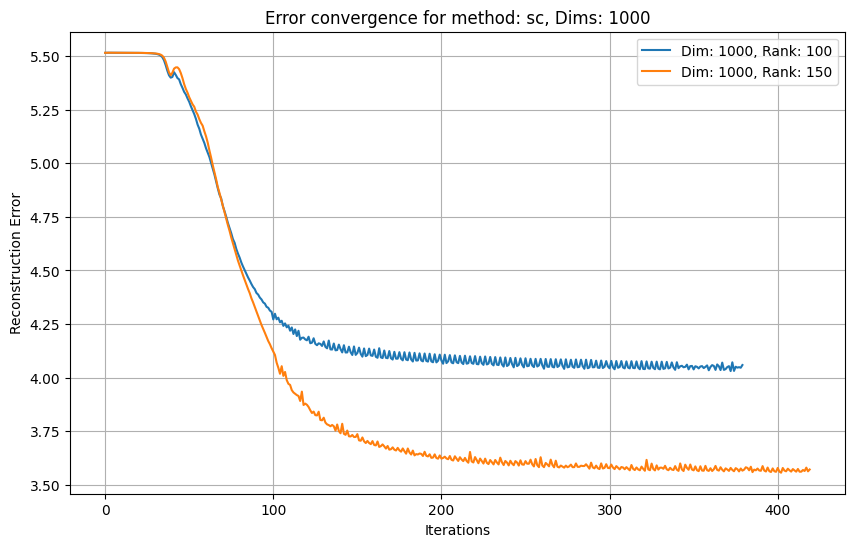

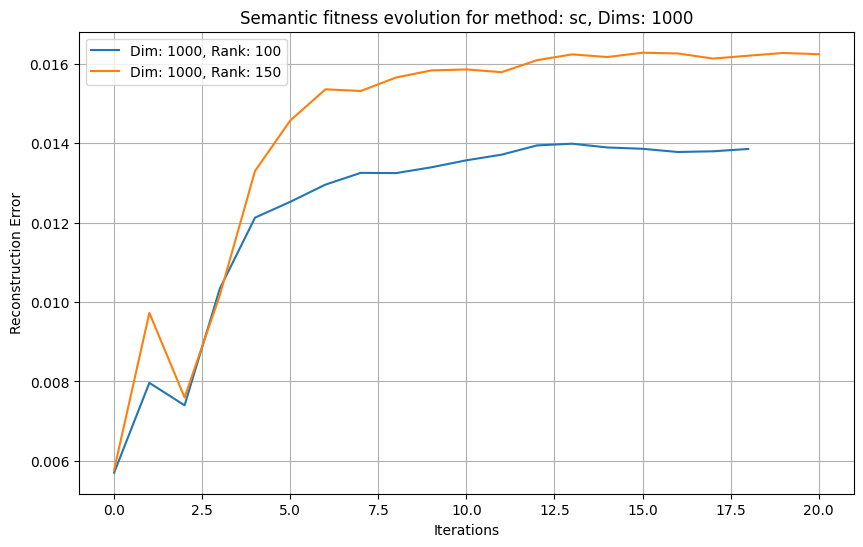

In [6]:
sem_errors = {}
methods = ["sc"]
dims = [1000]
ranks = [100, 150]
iters = 1000
name = "kl"
for rank in ranks:
        for dim in dims:
            for method in methods:
                try:
                    error = np.load(errors_dir / f"{name}_{method}_{dim}d_{rank}r_{iters}i_errors.npy")
                    sem_error = np.load(errors_dir / f"{name}_{method}_{dim}d_{rank}r_{iters}i_fitness.npy")
                    errors[(method, dim, rank)] = error
                    sem_errors[(method, dim, rank)] = sem_error
                    print(f"Loaded error for {method} dim {dim} rank {rank}: {sem_error[-1]}")
                except FileNotFoundError:
                    print(f"File not found for {method} dim {dim} rank {rank}")
# we plot the errors for each method, dim and rank

for method in methods:
    for dim in dims:
        plt.figure(figsize=(10, 6))
        for rank in ranks:
            key = (method, dim, rank)
            if key in sem_errors:
                plt.plot(errors[key], label=f"Dim: {dim}, Rank: {rank}")
        plt.title(f"Error convergence for method: {method}, Dims: {dim}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()

for method in methods:
    for dim in dims:
        plt.figure(figsize=(10, 6))
        for rank in ranks:
            key = (method, dim, rank)
            if key in sem_errors:
                plt.plot(sem_errors[key], label=f"Dim: {dim}, Rank: {rank}")
        plt.title(f"Semantic fitness evolution for method: {method}, Dims: {dim}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()


In [7]:
sem_errors = {}
methods = ["sc"]
dims = [1000]
ranks = [150]
iters = 1000
names = ["sim", "kl"]
for rank in ranks:
        for dim in dims:
            for method in methods:
                for name in names:
                    try:
                        base_name = f"{name+'_'}{method}_{dim}d_{rank}r_{2000 if name == "sim" else 1000}i"
                        error_name = f"{base_name}_errors.npy"
                        sem_error_name = f"{base_name}_fitness.npy"
                        error = np.load(errors_dir / error_name)
                        sem_error = np.load(errors_dir / sem_error_name)
                        errors[(name, method, dim, rank)] = error
                        sem_errors[(name, method, dim, rank)] = sem_error
                    except FileNotFoundError:
                        print(f"File not found for {name} dim {dim} rank {rank}")



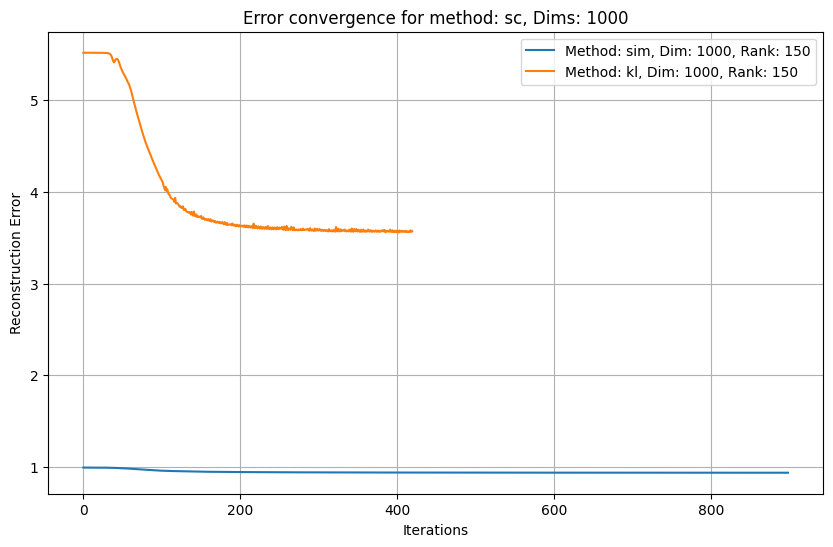

In [8]:
# we plot the two methods together
for method in methods:
    for dim in dims:
        plt.figure(figsize=(10, 6))
        for name in names:
            key = (name, method, dim, ranks[0])
            if key in errors:
                plt.plot(errors[key], label=f"Method: {name}, Dim: {dim}, Rank: {ranks[0]}")
        plt.title(f"Error convergence for method: {method}, Dims: {dim}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()

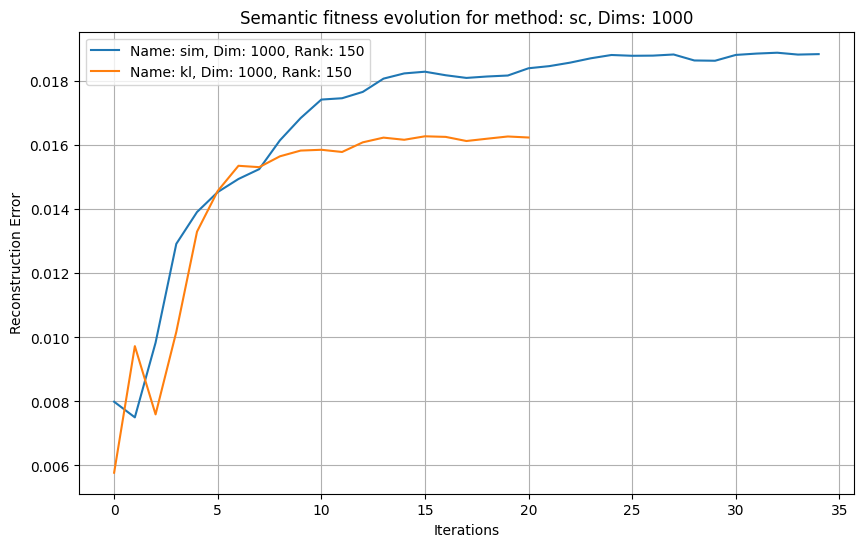

In [9]:
# semantic
rank = ranks[0]
for method in methods:
    for dim in dims:
        plt.figure(figsize=(10, 6))
        for name in names:
            key = (name, method, dim, rank)
            if key in sem_errors:
                plt.plot(sem_errors[key], label=f"Name: {name}, Dim: {dim}, Rank: {rank}")
        plt.title(f"Semantic fitness evolution for method: {method}, Dims: {dim}")
        plt.xlabel("Iterations")
        plt.ylabel("Reconstruction Error")
        plt.legend()
        plt.grid(True)
        plt.show()

Loaded error for kl sc dim 1000 rank 100: 0.015075138177963859
Loaded error for klNoB sc dim 1000 rank 100: 0.015072319271795488
Loaded error for kl sc dim 1000 rank 100: 0.013856982431714394
File not found for sc dim 1000 rank 100 name klNoB iter 1000
File not found for sc dim 2000 rank 100 name kl iter 250
File not found for sc dim 2000 rank 100 name klNoB iter 250
File not found for sc dim 2000 rank 100 name kl iter 1000
Loaded error for klNoB sc dim 2000 rank 100: 0.016614817913699828
File not found for sc dim 3000 rank 100 name kl iter 250
File not found for sc dim 3000 rank 100 name klNoB iter 250
File not found for sc dim 3000 rank 100 name kl iter 1000
Loaded error for klNoB sc dim 3000 rank 100: 0.015200179220966368
File not found for sc dim 1000 rank 150 name kl iter 250
File not found for sc dim 1000 rank 150 name klNoB iter 250
Loaded error for kl sc dim 1000 rank 150: 0.016243734553230967
File not found for sc dim 1000 rank 150 name klNoB iter 1000
File not found for sc di

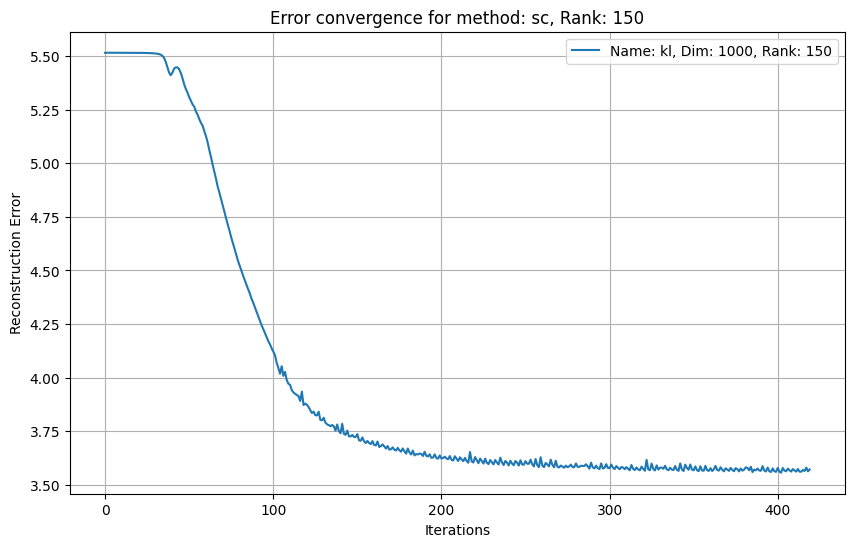

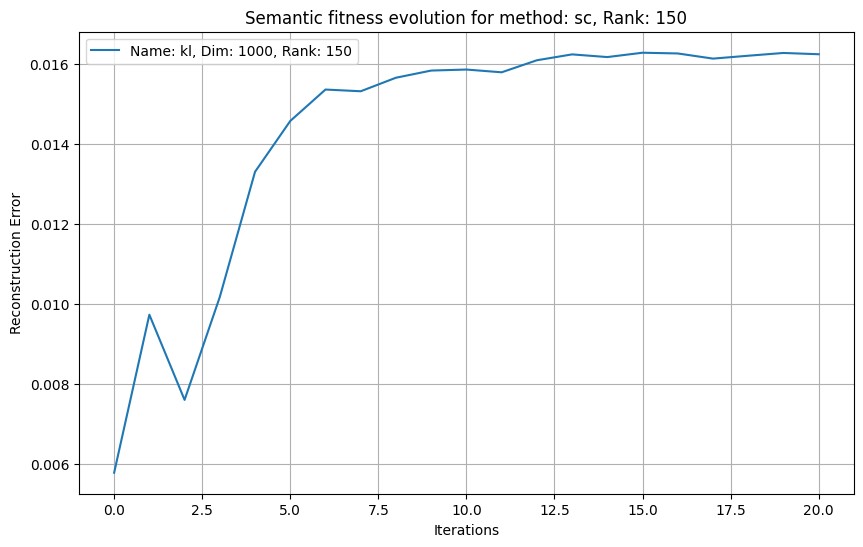

In [10]:
errors = {}
sem_errors = {}
methods = ["sc"]
method = methods[0]
dims = [1000, 2000, 3000]
ranks = [100, 150]
iters = [250, 1000]
names = ["kl", "klNoB"]
for rank in ranks:
        for dim in dims:
            for method in methods:
                for iter in iters:
                    for name in names:
                        try:
                            error = np.load(errors_dir / f"{name}_{method}_{dim}d_{rank}r_{iter}i_errors.npy")
                            sem_error = np.load(errors_dir / f"{name}_{method}_{dim}d_{rank}r_{iter}i_fitness.npy")
                            errors[(name, method, dim, rank)] = error
                            sem_errors[(name, method, dim, rank)] = sem_error
                            print(f"Loaded error for {name} {method} dim {dim} rank {rank}: {sem_error[-1]}")
                        except FileNotFoundError:
                            print(f"File not found for {method} dim {dim} rank {rank} name {name} iter {iter}")
# we plot the errors for each method, dim and rank
dim = 1000

plt.figure(figsize=(10, 6))
for name in names:
    key = (name, method, dim, rank)
    if key in errors:
        plt.plot(errors[key], label=f"Name: {name}, Dim: {dim}, Rank: {rank}")
plt.title(f"Error convergence for method: {method}, Rank: {rank}")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 6))
for name in names:
    key = (name, method, dim, rank)
    if key in sem_errors:
        plt.plot(sem_errors[key], label=f"Name: {name}, Dim: {dim}, Rank: {rank}")
plt.title(f"Semantic fitness evolution for method: {method}, Rank: {rank}")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
errors.keys()

dict_keys([('kl', 'sc', 1000, 100), ('klNoB', 'sc', 1000, 100), ('klNoB', 'sc', 2000, 100), ('klNoB', 'sc', 3000, 100), ('kl', 'sc', 1000, 150), ('klNoB', 'sc', 3000, 150)])

In [17]:
sem_errors.keys()

dict_keys([('kl', 'sc', 1000, 100), ('klNoB', 'sc', 1000, 100), ('klNoB', 'sc', 2000, 100), ('klNoB', 'sc', 3000, 100), ('kl', 'sc', 1000, 150), ('klNoB', 'sc', 3000, 150)])

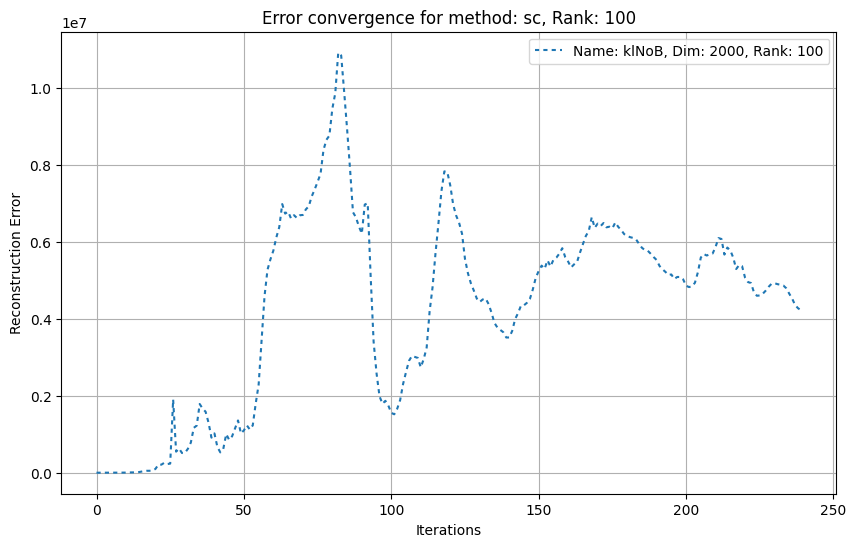

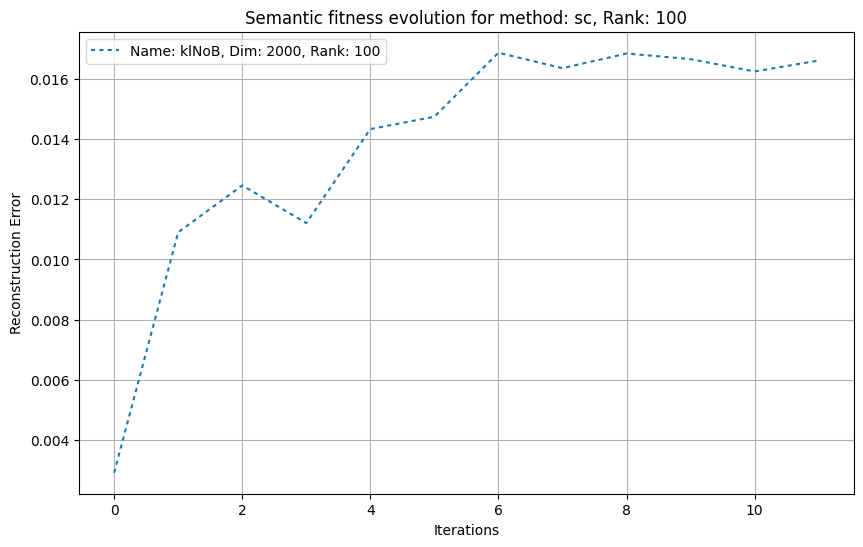

In [18]:
dim = 2000
iter = 1000
name = "klNoB"
rank = 100
# python
plt.figure(figsize=(10, 6))
dash_patterns = [(5, 2), (2, 2)]  # different dash sequences for each series

for i, name in enumerate(names):
    key = (name, method, dim, rank)
    if key in errors:
        line, = plt.plot(
            errors[key],
            label=f"Name: {name}, Dim: {dim}, Rank: {rank}",
            linestyle='--',
            linewidth=1.5,
        )
        line.set_dashes(dash_patterns[i % len(dash_patterns)])
plt.title(f"Error convergence for method: {method}, Rank: {rank}")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
for i, name in enumerate(names):
    key = (name, method, dim, rank)
    if key in sem_errors:
        line, = plt.plot(
            sem_errors[key],
            label=f"Name: {name}, Dim: {dim}, Rank: {rank}",
            linestyle='--',
            linewidth=1.5,
        )
        line.set_dashes(dash_patterns[i % len(dash_patterns)])
plt.title(f"Semantic fitness evolution for method: {method}, Rank: {rank}")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

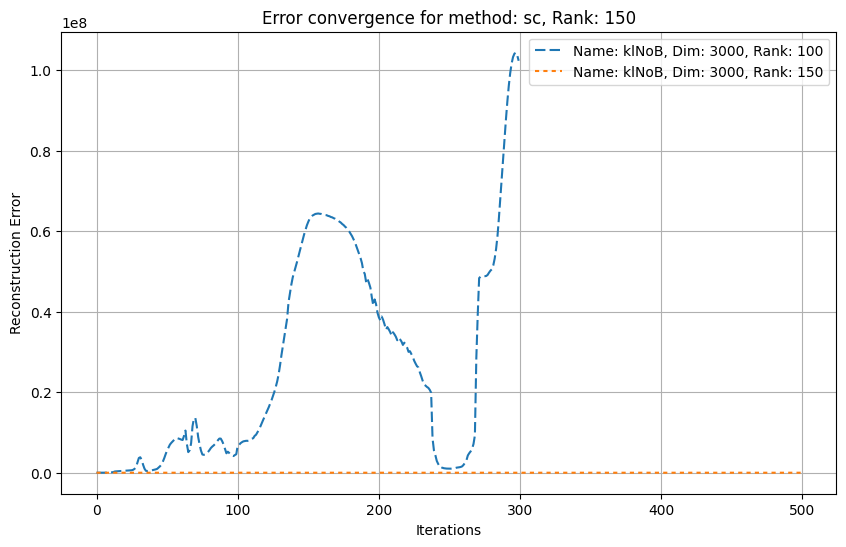

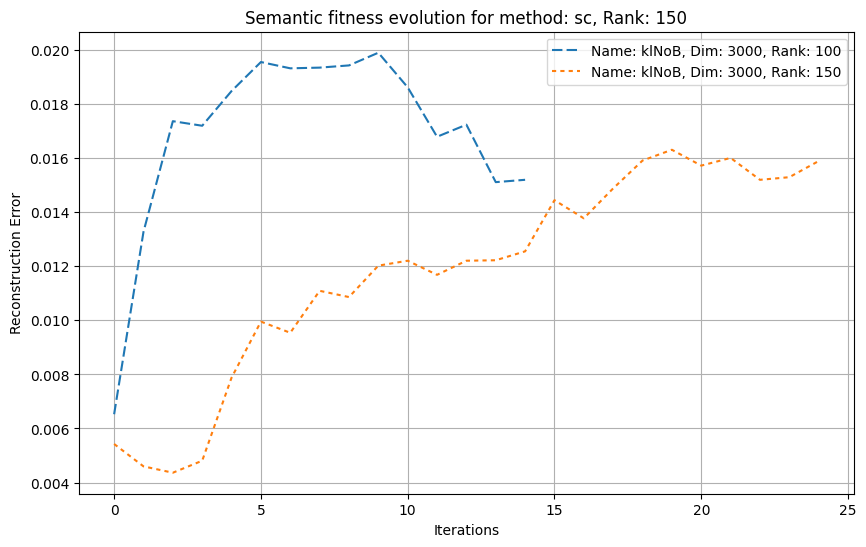

In [19]:
# python
dim = 3000
plt.figure(figsize=(10, 6))
dash_patterns = [(5, 2), (2, 2)]  # different dash sequences for each series
for i, rank in enumerate(ranks):
    key = (name, method, dim, rank)
    if key in errors:
        line, = plt.plot(
            errors[key],
            label=f"Name: {name}, Dim: {dim}, Rank: {rank}",
            linestyle='--',
            linewidth=1.5,
        )
        line.set_dashes(dash_patterns[i % len(dash_patterns)])
plt.title(f"Error convergence for method: {method}, Rank: {rank}")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))

for i, rank in enumerate(ranks):
    key = (name, method, dim, rank)
    if key in sem_errors:
        line, = plt.plot(
            sem_errors[key],
            label=f"Name: {name}, Dim: {dim}, Rank: {rank}",
            linestyle='--',
            linewidth=1.5,
        )
        line.set_dashes(dash_patterns[i % len(dash_patterns)])
plt.title(f"Semantic fitness evolution for method: {method}, Rank: {rank}")
plt.xlabel("Iterations")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()